# HW 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

%matplotlib inline

# Загружаем выборку Diamonds

На данной выборке можно проверять работоспособность своего решения

1. PRICE: price in US dollars (326-18,823)
2. CARAT: weight of the diamond (0.2--5.01)
3. CUT: quality of the cut (Fair, Good, Very Good, Premium, Ideal)
4. COLOR: diamond colour, from J (worst) to D (best)
5. CLARITY: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
6. X: length in mm (0--10.74)
7. Y: width in mm (0--58.9)
8. Z: depth in mm (0--31.8)
9. DEPTH: total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
10. TABLE: width of top of diamond relative to widest point (43--95)

In [ ]:
diamonds_df = pd.read_csv('diamonds.csv')

In [ ]:
diamonds_df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


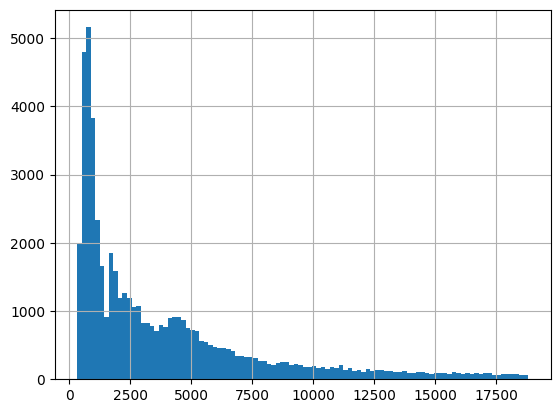

In [ ]:
plt.hist(diamonds_df['price'], bins=100)
plt.grid();

# Подготовка данных

In [ ]:
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
target = ['price']

In [ ]:
cut_transform = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
clarity_transform = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}
color_transorm = {'D': 0, 'E': 1, 'F': 2, 'G': 3, 'H': 4, 'I': 5, 'J': 6}

In [ ]:
diamonds_df['cut'] = diamonds_df['cut'].apply(lambda x: cut_transform.get(x))
diamonds_df['color'] = diamonds_df['color'].apply(lambda x: color_transorm.get(x))
diamonds_df['clarity'] = diamonds_df['clarity'].apply(lambda x: clarity_transform.get(x))

In [ ]:
X = diamonds_df[features].copy().values
y = diamonds_df[target].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=47, test_size=0.3)

In [ ]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Обучаем модель линейной регрессии

In [ ]:
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
y_pred = reg.predict(X_test)

In [ ]:
score = r2_score(y_pred, y_test)

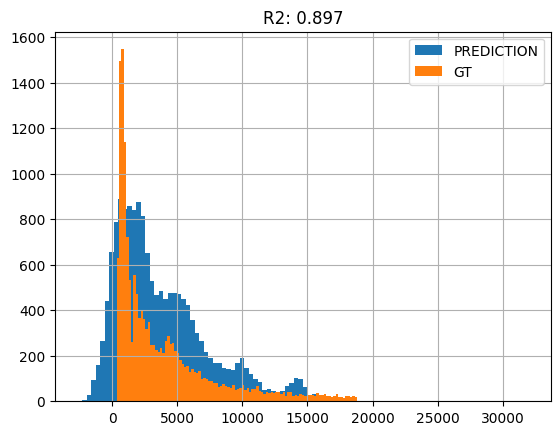

In [ ]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();

# Задание 1: Реализация Gradient Descent для модели линейной регрессии

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [ ]:
class LinearRegressorGD:
    """
    Линейная регрессия с использованием Gradient Descent
    """

    def __init__(self, learning_rate=0.01, n_iter=1000,  tol=0.001, early_stopping=False, n_iter_no_change=5):
        """
        Конструктор класса

        Параметры:
            learning_rate (float): Скорость обучения
            n_iter (int): Количество итераций градиентного спуска
            tol (float): минимальное изменение градиента
            early_stopping (bool): ранняя остановка
            n_iter_no_change (int): кол-во итераций изменения градиента

        """
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.tol = tol
        self.early_stopping = early_stopping
        self.n_iter_no_change = n_iter_no_change

        self.weights = None
        self.bias = None

    def fit(self, X, y):
        """
        Обучение модели на обучающей выборке с использованием
        градиентного спуска

        Параметры:
            X (np.ndarray): Матрица признаков размера (n_samples, n_features)
            y (np.ndarray): Вектор таргета длины n_samples
        """
        y = y.ravel() #чтоб был вектор

        #инициализация весов
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        no_improve = 0
        best_loss = float("inf")

        #градиентный спуск
        for i in range(self.n_iter):
          y_pred = np.dot(X, self.weights) + self.bias
          delta = y_pred - y
          if i % 1000 == 0:
            R2 = 1 - np.sum(delta ** 2) / np.sum((y - y.mean()) ** 2)
            print(f"№{i}: R2 = {R2}")

          dW = 2 * np.dot(X.T, delta) / n_samples
          db = 2 * np.sum(delta) / n_samples

          self.weights -= self.learning_rate * dW
          self.bias -= self.learning_rate * db

          if self.early_stopping:
                mse_loss = np.mean((np.dot(X, self.weights) + self.bias - y) ** 2)
                if mse_loss + self.tol < best_loss:
                    best_loss = mse_loss
                    no_improve = 0
                else:
                    no_improve += 1
                    if no_improve >= self.n_iter_no_change:
                        break



    def predict(self, X):
        """
        Получение предсказаний обученной модели

        Параметры:
            X (np.ndarray): Матрица признаков

        Возвращает:
            np.ndarray: Предсказание для каждого элемента из X
        """
        return np.dot(X, self.weights) + self.bias

    def get_params(self):
        """
        Возвращает обученные параметры модели
        """
        return self.weights, self.bias


## Тест модели

In [ ]:
my_reg = LinearRegressorGD(learning_rate=0.01, n_iter=10000, early_stopping=True)
my_reg.fit(X_train, y_train)

№0: R2 = -0.9799471993525852
№1000: R2 = 0.460691144123219
№2000: R2 = 0.6304100035820723
№3000: R2 = 0.7281539861395007
№4000: R2 = 0.7872642614034476
№5000: R2 = 0.8233235687630043
№6000: R2 = 0.8454101339022191
№7000: R2 = 0.8590024561578125
№8000: R2 = 0.8674264039587204
№9000: R2 = 0.8727032940189515


In [ ]:
y_pred = my_reg.predict(X_test)

In [ ]:
score = r2_score(y_test, y_pred)
score

0.8765501021426316

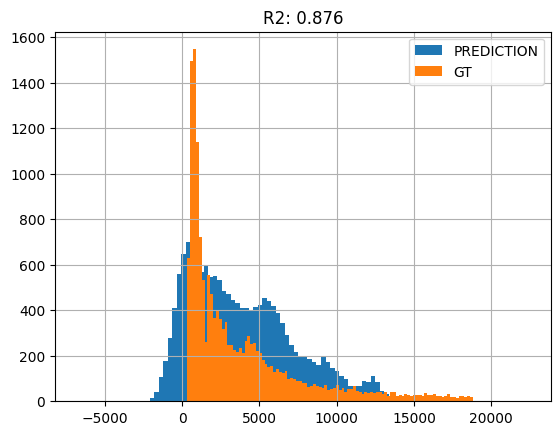

In [ ]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();

# Задание 2: Реализация backpropagation для MLP

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

В качестве функции активации на внутренних слоях нужно использовать Sigmoid, а на выходе - линейную активацию f(x) = x

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [ ]:
class MLPRegressor:
    """
    Многослойный перцептрон (MLP) для задачи регрессии, использующий алгоритм
    обратного распространения ошибки
    """

    def __init__(self, hidden_layer_sizes=(100, 50), learning_rate=0.01, n_iter=100):
        """
        Конструктор класса

        Параметры:
            hidden_layer_sizes (tuple): Кортеж, определяющий архитектуру
        скрытых слоев. Например (100, 10) - два скрытых слоя, размером 100 и 10
        нейронов, соответственно
            learning_rate (float): Скорость обучения
            n_iter (int): Количество итераций градиентного спуска
        """
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate
        self.n_iter = n_iter

        self.count_hidden_layer_sizes = len(hidden_layer_sizes)
        self.output_layer_sizes = (1,)

        self.weights = []
        self.bias = []


    def create_weights(self):
        '''
          Генерация весов и биас

        '''
        weights = []
        bias_weights = []

        # Общее кол-во слоев: [input, hidden, output]
        layer_sizes = [self.input_layer_sizes[0]] + list(self.hidden_layer_sizes) + [self.output_layer_sizes[0]]

        for i in range(len(layer_sizes) - 1):
            # веса между слоями
            weights_generated = np.random.randn(layer_sizes[i], layer_sizes[i + 1])
            bias_generated = np.zeros((1, layer_sizes[i + 1]))

            weights.append(weights_generated)
            bias_weights.append(bias_generated)

        return weights, bias_weights


    @staticmethod
    def sigmoid_calc(x):

        '''Вычисление сигмоиды'''

        return 1 / (1 + np.exp(-x))


    def sigmoid_deriv(self, x):

        '''Производная сигмоиды'''

        sigmoid = self.sigmoid_calc(x)
        return sigmoid * (1 - sigmoid)


    @staticmethod
    def linear_calc(x):

        '''линейная ф-ия для выходного слоя f(x) = x'''

        return x

    @staticmethod
    def linear_deriv(x):

        '''Производная линейной ф-ии'''

        return np.ones_like(x)

    @staticmethod
    def mse_calc(output, y):

        '''mse'''

        return np.mean(np.square(y - output))

    @staticmethod
    def mse_deriv(output, y):

        '''Производная mse'''

        return ((-2) * (y - output)) / (y.size)



    def forward(self, X):

        '''Активация нейронов'''

        activated_data = [X] # X - входная матрица
        not_activated_data = [] #значения до ф-ии активации

        for i in range(len(self.weights) - 1):

            no_activated = np.dot(activated_data[-1], self.weights[i]) + self.bias[i] # умножение на веса

            activated = self.sigmoid_calc(no_activated) # применение ф-ии активации

            activated_data.append(activated)
            not_activated_data.append(no_activated)

        # Выходной слой через линейную ф-ию

        no_activated_output = np.dot(activated_data[-1], self.weights[-1]) + self.bias[-1]
        output = self.linear_calc(no_activated_output)

        not_activated_data.append(no_activated_output)
        activated_data.append(output)

        return not_activated_data,  activated_data



    def backward(self, not_activated_data, activated_data, y):

        '''
        Алгоритм Back propagation:
        пусть t - данные до активации (not_activated_data)
        пусть h = F(t), h - данные после активации (activated_data), F - функция активации
        E = mse

        1) Считаем локальную производную delta_out выходного слоя :
            delta_out = dE/dt_out = dE/dh_out *(поэлементно) F'(t_out). Ф-ия активации выходного слоя F(x) = x
        2) Считаем локальные производные delta на скрытых слоях. (Зная локальные производные слоя справа)
            delta_1 = dE/dt_1 = dE/dh_1 *(поэлементно) F'(t_1) = dE/dt_2 * W_2^T *(поэлементно) F'(t_1). Ф-ия активации скрытых слоев F(x) сигмоида
        3) Считаем производные dW, db (Зная локальные производные)
            dE/dW_2 = h_1^T * dE/dt_out
            dE/db_2 = dE/dt_out
            и тд
        4) Смещаем веса и биас

        '''

        deltas = []

        # Выходной слой (п.1 алгоритма)
        mse_error_deriv = self.mse_deriv(output = activated_data[-1], y = y)
        delta = mse_error_deriv * self.linear_deriv(x = not_activated_data[-1])
        deltas.append(delta)

        # Скрытые слои (п.2 алгоритма)
        for i in reversed(range(len(self.weights) - 1)):
            delta = np.dot(deltas[-1], self.weights[i + 1].T) * self.sigmoid_deriv(not_activated_data[i])
            deltas.append(delta)

        deltas.reverse()

        # Производные W b и градиентный спуск
        for i in range(len(self.weights)):

            dW = np.dot(activated_data[i].T, deltas[i])
            db = np.sum(deltas[i], axis=0, keepdims=True)

            self.weights[i] -= self.learning_rate * dW
            self.bias[i] -= self.learning_rate * db


    def fit(self, X, y):

        '''Обучение модели'''

        self.input_layer_sizes = (X.shape[1],)
        self.weights, self.bias = self.create_weights()

        for i in range(self.n_iter):

            not_activated_data, activated_data = self.forward(X)

            loss = self.mse_calc(output = activated_data[-1], y = y)

            self.backward(not_activated_data = not_activated_data, activated_data = activated_data, y = y)

            if i % 10 == 0:
                print(f"Loss for epoch №{i+1}: {loss:.4f}")

        print('Train finish')



    def predict(self, X):

        '''Предсказание модели'''

        not_activated_data, activated_data = self.forward(X)
        return activated_data[-1]


In [ ]:
mlp = MLPRegressor(hidden_layer_sizes=(130, ), learning_rate=0.001, n_iter=1050)

In [ ]:
mlp.fit(X_train, y_train)

Loss for epoch №1: 31598407.6399
Loss for epoch №11: 16086380.9118
Loss for epoch №21: 15849184.8623
Loss for epoch №31: 15874027.6018
Loss for epoch №41: 15892919.2779
Loss for epoch №51: 15791721.1501
Loss for epoch №61: 15722466.5809
Loss for epoch №71: 15699199.1026
Loss for epoch №81: 15493100.9545
Loss for epoch №91: 15479568.8757
Loss for epoch №101: 15307278.6974
Loss for epoch №111: 14776092.8158
Loss for epoch №121: 14467633.2554
Loss for epoch №131: 14166619.9315
Loss for epoch №141: 14343000.1879
Loss for epoch №151: 13645221.0602
Loss for epoch №161: 13322095.8508
Loss for epoch №171: 12754223.4389
Loss for epoch №181: 12511203.9006
Loss for epoch №191: 12225765.8543
Loss for epoch №201: 12305315.4192
Loss for epoch №211: 10619839.6315
Loss for epoch №221: 11655827.5551
Loss for epoch №231: 11689084.4071
Loss for epoch №241: 11615037.9200
Loss for epoch №251: 11585408.1667
Loss for epoch №261: 9261141.8290
Loss for epoch №271: 9417650.1005
Loss for epoch №281: 8748134.6061

In [ ]:
y_pred = mlp.predict(X_test)

In [ ]:
score = r2_score(y_test, y_pred)
score

0.9260554265051611

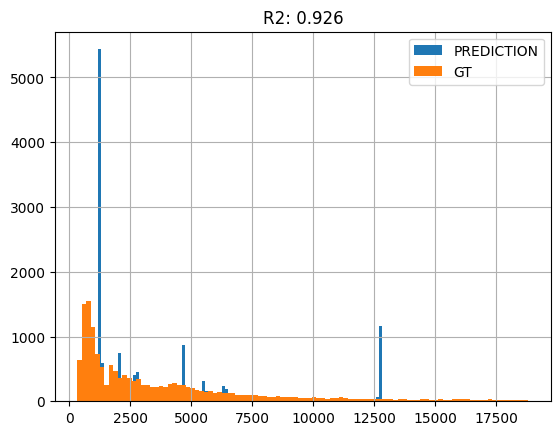

In [ ]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();